<a href="https://colab.research.google.com/github/harishmuh/Python-for-Data-Science-Analysis/blob/main/Statistics_inferential_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Inferential Statistics Exercises**

### **Topic Understanding**

1. What is meant by population and sample? Give an example!

`Population`:
- a collection of all observations, calculations, or measurements on the topic being studied (all data)

`Sample`:
- a subset of the population and represents the population

> Case example: calculating the average high school national exam score in 2025
>- Population: all high school students in Indonesia
>- Sample: a portion of high school students in Indonesia, for example, 100 students randomly selected from each district

2. What is meant by hypothesis? What is the difference between the Null Hypothesis (Ho) and the Alternative Hypothesis (Ha)? Give an example!

Hypothesis:
- A statement about the population.

Hypothesis Testing:
- Inferring population parameters based on sample statistics.

H0 vs H1:
- H0: A statement that nothing new occurs, the old theory is true (a statement about what already exists).
- H1: A statement that something new occurs, the new theory is true (a statement about something to be proven).

Example:
- Ho: The average height of Indonesians is 150 cm (mean = 150 cm).
- Ha: The average height of Indonesians is greater than 150 cm (mean > 150 cm).

### **One-tailed vs. Two-tailed**

If we wanted to conduct an experiment or survey to prove the questions below, which test would be more appropriate (a one-tailed or a two-tailed test)?

1. Is the average height of Indonesians in 2000 and 2020 **different**?
- Two-tailed
2. Is the average IELTS score at international schools in Jakarta **higher** than at public schools?
- One-tailed
3. Do people who regularly cycle have **lower** body fat levels than those who rarely exercise?
- One-tailed
4. Is the average weight of a small sack of rice produced by Company A **5,000g**?
- Two-tailed
5. Did the number of students who passed the 2010 National Exam **95%**?
- Two-tailed



### Statistical Tests
1. Of the 5 internet providers in Indonesia, did they all have the same average income in 2020?
- One-Way ANOVA
2. Do people who regularly cycle have lower body fat levels than before they started exercising?
- Two-Sample paired t-Test
3. Do people who regularly cycle have lower body fat levels than people who rarely exercise?
- Two-Sample unpaired t-Test
4. Is the average weight of a small sack of rice produced by Company A 5,000g?
- One-Sample t-Test
5. Did the number of students who passed the 2010 National Exam exceed 95%?
- One-Sample Z-Test

### **Statistical Test Practice**

In [1]:
# import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt


In [4]:
# Loading dataset
df_car_csv = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vSbFVzCI9w7S4l3bdrTjR9saajaHuH3MJO5i3Fl4M9aGI8uY8ii3ZWS0kVnkJ5wENGqSXpyo-34fMcM/pub?gid=116408873&single=true&output=csv'
df_car = pd.read_csv(df_car_csv).drop(columns='Unnamed: 0')
df_car.head()

,brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Audi,A1,2017,12500,Manual,15735,Petrol,150,55.4,1.4
1,Audi,A6,2016,16500,Automatic,36203,Diesel,20,64.2,2.0
2,Audi,A1,2016,11000,Manual,29946,Petrol,30,55.4,1.4
3,Audi,A4,2017,16800,Automatic,25952,Diesel,145,67.3,2.0
4,Audi,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0


In [6]:
# data summary
df_car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22038 entries, 0 to 22037
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         22038 non-null  object 
 1   model         22038 non-null  object 
 2   year          22038 non-null  int64  
 3   price         22038 non-null  int64  
 4   transmission  22038 non-null  object 
 5   mileage       22038 non-null  int64  
 6   fuelType      22038 non-null  object 
 7   tax           22038 non-null  int64  
 8   mpg           22038 non-null  float64
 9   engineSize    22038 non-null  float64
dtypes: float64(2), int64(4), object(4)
memory usage: 1.7+ MB


In [7]:
# descriptive statistic
display(df_car.describe(), df_car.describe(include='object'))

,year,price,mileage,tax,mpg,engineSize
count,22038.000000,22038.000000,22038.000000,22038.000000,22038.000000,22038.000000
mean,2016.982303,17522.086033,23613.609946,115.353934,55.208531,1.690453
std,2.134123,10587.356894,21063.202824,69.024931,14.851751,0.566645
min,1997.000000,850.000000,1.000000,0.000000,1.100000,0.000000
25%,2016.000000,9999.000000,7446.250000,30.000000,45.600000,1.400000
50%,2017.000000,14999.000000,18539.500000,145.000000,55.400000,1.600000
75%,2019.000000,21990.000000,33186.750000,145.000000,64.200000,2.000000
max,2020.000000,145000.000000,323000.000000,580.000000,256.800000,6.300000


,brand,model,transmission,fuelType
count,22038,22038,22038,22038
unique,3,60,4,4
top,Audi,Yaris,Manual,Petrol
freq,10565,2117,11656,11896


#### **Questions**

1. Do Hyundai and Toyota automatic cars have different prices? Prove it with statistical tests?

In [5]:
df_automatic_ht = df_car[(df_car['brand'].isin(['Toyota', 'Hyundai'])) & (df_car['transmission'] == "Automatic")]
df_automatic_ht.head()

,brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
10566,Hyundai,Tucson,2016,14499,Automatic,25233,Diesel,235,43.5,2.0
10572,Hyundai,Tucson,2016,14199,Automatic,30300,Diesel,125,57.6,1.7
10573,Hyundai,I30,2018,10399,Automatic,38082,Petrol,145,51.4,1.4
10594,Hyundai,Tucson,2016,15800,Automatic,20025,Diesel,125,57.6,1.7
10595,Hyundai,Ioniq,2018,15000,Automatic,32227,Hybrid,135,78.5,1.6


**Check Price Normality**

In [8]:
from scipy.stats import normaltest

stat, pvalue = normaltest(df_automatic_ht['price'])

if pvalue > 0.05 :
  print(f'pvalue = {pvalue:.5f}, we assume the car price data is normally distributed')
else :
  print(f'pvalue = {pvalue:.5f}, we assume the car price data is NOT normally distributed')

pvalue = 0.00000, we assume the car price data is NOT normally distributed


**Check Price Normality for Each Brand**

In [9]:
stat, pvalue = normaltest(df_automatic_ht[df_automatic_ht['brand']=='Toyota']['price'])

if pvalue > 0.05 :
  print(f'pvalue = {pvalue:.5f}, we assume the Toyota car price data is normally distributed')
else :
  print(f'pvalue = {pvalue:.5f}, we assume the Toyota car price data is NOT normally distributed')

pvalue = 0.00000, we assume the Toyota car price data is NOT normally distributed


In [10]:
stat, pvalue = normaltest(df_automatic_ht[df_automatic_ht['brand']=='Hyundai']['price'])

if pvalue > 0.05 :
  print(f'pvalue = {pvalue:.5f}, we assume the Hyundai car price data is normally distributed')
else :
  print(f'pvalue = {pvalue:.5f}, we assume the Hyundai car price data is NOT normally distributed')

pvalue = 0.00000, we assume the Hyundai car price data is NOT normally distributed


**Hypothesis Test**

- Categorical Column (brand) vs. Numerical Column (price)
- Not Normally Distributed
- 2 Sample Groups (Hyundai and Toyota)

In [11]:
from scipy.stats import mannwhitneyu

# Hypothesis
print('Hypothesis')
print('Ho: Median price of Hyundai Automatic = Median price of Toyota Automatic')
print('Ha: Median price of Hyundai Automatic != Median price of Toyota Automatic')

# Statistical Test
stat, pvalue = mannwhitneyu(
df_automatic_ht[df_automatic_ht['brand']=='Hyundai']['price'],
df_automatic_ht[df_automatic_ht['brand']=='Toyota']['price'],
alternative='two-sided'
)

# Conclusion
if pvalue > 0.05 :
  print(f'''
pvalue = {pvalue:.5f}. pvalue > 0.05. Failed to reject Ho.
We do NOT have enough evidence to say that the Median price of Hyundai Automatic is NOT EQUAL to Median price of Toyota Automatic
(The medians are NOT significantly different)
''')
else:
  print(f'''
pvalue = {pvalue:.5f}. pvalue <= 0.05. Successfully rejecting Ho.
We have sufficient evidence to say that the median price of Hyundai Automatic
is NOT the same as the median price of Toyota Automatic
(The medians are significantly different)
''')

Hypothesis
Ho: Median price of Hyundai Automatic = Median price of Toyota Automatic
Ha: Median price of Hyundai Automatic != Median price of Toyota Automatic

pvalue = 0.41889. pvalue > 0.05. Failed to reject Ho.
We do NOT have enough evidence to say that the Median price of Hyundai Automatic is NOT EQUAL to Median price of Toyota Automatic
(The medians are NOT significantly different)



2. What is the relationship between the numerical variables in the all_cars dataset? Which variable has the strongest relationship? Prove it using statistical tests!

Before determining which correlation test that we will use, we need to conduct normality test on all numerical variables

In [12]:
# Data distribution check # Normality check
numerical = [var for var in df_car.columns if df_car[var].dtypes not in ['object']]

from scipy.stats import normaltest

dist = []

for i in range(len(numerical)):
    feature_name = numerical[i]
    stat, p_value = normaltest(df_car[feature_name].dropna())

    if p_value > 0.05:
        distribution = "Normally Distributed"
    else:
        distribution = "Not Normally Distributed"

    dist.append([feature_name, stat, p_value, distribution])

dist_df = pd.DataFrame(dist, columns=['Feature', "D'Agostino-Pearson Statistic", 'P-value', 'Distributed'])
dist_df

,Feature,D'Agostino-Pearson Statistic,P-value,Distributed
0,year,8640.965866,0.0,Not Normally Distributed
1,price,11898.442659,0.0,Not Normally Distributed
2,mileage,7864.194541,0.0,Not Normally Distributed
3,tax,1536.821931,0.0,Not Normally Distributed
4,mpg,13956.966736,0.0,Not Normally Distributed
5,engineSize,5252.128689,0.0,Not Normally Distributed


We will use heatmap correlation graph to visualize the relatioship between variables. The correlation will be calculated by using spearman as most of variables have non normally distributed data

In [13]:
# spearman correlation #
df_car_corr = df_car.select_dtypes(include=np.number).corr(method='spearman')


# Improving display
df_car_corr.style.background_gradient(cmap='coolwarm')

,year,price,mileage,tax,mpg,engineSize
year,1.000000,0.558739,-0.812749,0.313273,-0.394185,0.019310
price,0.558739,1.000000,-0.449369,0.326304,-0.532437,0.648922
mileage,-0.812749,-0.449369,1.000000,-0.230232,0.356815,0.089156
tax,0.313273,0.326304,-0.230232,1.000000,-0.657805,0.227783
mpg,-0.394185,-0.532437,0.356815,-0.657805,1.000000,-0.350462
engineSize,0.019310,0.648922,0.089156,0.227783,-0.350462,1.000000


* year vs mileage has the strongest negative correlation (r = -0.81).

  * This means newer cars tend to have lower mileage, which makes intuitive sense.
* price vs engineSize (r ≈ +0.65): bigger engine cars tend to be more expensive.
* mpg vs tax and mpg vs engineSize show negative correlation, meaning larger engines and higher taxes are associated with lower fuel efficiency (mpg).



3. Are the mileages of all car brands released in 2019 the same? Prove it with a statistical test!

In [14]:
# Create a dataframe containing cars manufactured in 2019
df_2019 = df_car[df_car["year"]==2019]
df_2019.head()

,brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
4,Audi,A3,2019,17300,Manual,1998,Petrol,145,49.6,1.0
45,Audi,A3,2019,15700,Manual,2029,Petrol,145,49.6,1.0
74,Audi,A3,2019,16000,Manual,5704,Petrol,145,49.6,1.0
90,Audi,A3,2019,25499,Semi-Auto,4000,Petrol,145,44.1,1.5
91,Audi,Q2,2019,25499,Semi-Auto,7897,Diesel,145,47.9,2.0


In [15]:
# Normality check # Milage # 2019
stat, pvalue = normaltest(df_2019['mileage'])

if pvalue > 0.05 :
  print(f'pvalue = {pvalue:.5f}, we assume the car mileage data is normally distributed')
else :
  print(f'pvalue = {pvalue:.5f}, we assume the car mileage data is NOT normally distributed')

pvalue = 0.00000, we assume the car mileage data is NOT normally distributed


In [16]:
# Normality check # Milage - Brand: Toyota # 2019
stat, pvalue = normaltest(df_2019[df_2019['brand']=="Toyota"]['mileage'])

if pvalue > 0.05 :
  print(f'pvalue = {pvalue:.5f}, we assume the Toyota car mileage data is normally distributed')
else :
  print(f'pvalue = {pvalue:.5f}, we assume the Toyota car mileage data is NOT normally distributed')

pvalue = 0.00000, we assume the Toyota car mileage data is NOT normally distributed


In [17]:
# Normality check # Milage - Brand: Hyundai # 2019
stat, pvalue = normaltest(df_2019[df_2019['brand']=="Hyundai"]['mileage'])

if pvalue > 0.05 :
  print(f'pvalue = {pvalue:.5f}, we assume the Toyota car mileage data is normally distributed')
else :
  print(f'pvalue = {pvalue:.5f}, we assume the Toyota car mileage data is NOT normally distributed')

pvalue = 0.00000, we assume the Toyota car mileage data is NOT normally distributed


In [18]:
# Normality check # Milage - Brand: Audi # 2019
stat, pvalue = normaltest(df_2019[df_2019['brand']=="Audi"]['mileage'])

if pvalue > 0.05 :
  print(f'pvalue = {pvalue:.5f}, we assume the Toyota car mileage data is normally distributed')
else :
  print(f'pvalue = {pvalue:.5f}, we assume the Toyota car mileage data is NOT normally distributed')

pvalue = 0.00000, we assume the Toyota car mileage data is NOT normally distributed


**Hypothesis Test**

- Categorical Column (brand) vs. Numerical Column (mileage)
- Not Normally Distributed
- 3 Sample Groups (Hyundai, Audi, and Toyota)

In [19]:
from scipy.stats import kruskal

# Hypothesis
print('Hypothesis')
print('Ho: All median mileages of different car brands are the same')
print('Ha: There is at least one median mileage of a different car brand')

# Statistical Test
stat, pvalue = kruskal(
  df_2019[df_2019['brand']=='Audi']['mileage'],
  df_2019[df_2019['brand']=='Hyundai']['mileage'],
  df_2019[df_2019['brand']=='Toyota']['mileage']
)

# Conclusion
if pvalue > 0.05 :
  print(f'''
  pvalue = {pvalue:.5f}. pvalue > 0.05. Failed to reject Ho.
  We do NOT have enough evidence to say that at least one of the car groups has a different median mileage.
''')
else :
  print(f'''
  pvalue = {pvalue:.5f}. pvalue <= 0.05. Successfully rejecting Ho.
  We have sufficient evidence to say that at least one of the car groups has a different median mileage.
''')

Hypothesis
Ho: All median mileages of different car brands are the same
Ha: There is at least one median mileage of a different car brand

  pvalue = 0.00185. pvalue <= 0.05. Successfully rejecting Ho.
  We have sufficient evidence to say that at least one of the car groups has a different median mileage.



4. Create a dataframe containing 2019 Hyundai and Toyota cars! From the dataframe you've created, conduct a hypothesis test to determine whether car brand is related to transmission type.

In [20]:
# Creating dataframe of hyundai and toyota in 2019
df_hyundai_toyota_19 = df_car[((df_car['brand']=='Hyundai')|(df_car['brand']=='Toyota')) & (df_car['year']==2019)]
df_hyundai_toyota_19

,brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
10578,Hyundai,Tucson,2019,17750,Manual,10000,Petrol,150,34.9,1.6
10601,Hyundai,Tucson,2019,18000,Manual,4353,Petrol,145,35.3,1.6
10605,Hyundai,I30,2019,14500,Manual,2481,Petrol,145,41.5,0.0
10623,Hyundai,I10,2019,8600,Manual,4920,Petrol,145,60.1,1.0
10627,Hyundai,Tucson,2019,15000,Manual,22397,Petrol,150,34.9,0.0
...,...,...,...,...,...,...,...,...,...,...
22018,Toyota,Camry,2019,26491,Automatic,4416,Hybrid,135,52.3,2.5
22019,Toyota,Camry,2019,27550,Automatic,4189,Hybrid,135,52.3,2.5
22020,Toyota,Camry,2019,25490,Automatic,6340,Hybrid,135,52.3,2.5
22021,Toyota,Camry,2019,26990,Automatic,3000,Hybrid,135,52.3,2.5


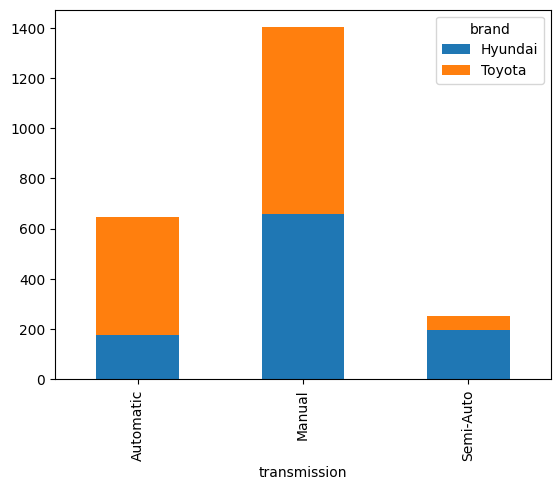

In [21]:
# Visualization
transmission_brand_19 =pd.crosstab(df_hyundai_toyota_19['transmission'], df_hyundai_toyota_19['brand'])
transmission_brand_19.plot(kind='bar', stacked=True)
plt.show()

In [ ]:
# Chi squarred test # Association test
from scipy.stats import chi2_contingency

stat, pvalue, dof, expected = chi2_contingency(
    pd.crosstab(df_hyundai_toyota_19['transmission'], df_hyundai_toyota_19['brand'])
)

alpha = 0.05  # significance

# Display the result
print(f"Chi squared statistics: {stat:.4f}")
print(f"P-value: {pvalue:.4f}")

if pvalue < alpha:
    print(f"pvalue = {pvalue:.5f}. pvalue > {alpha}. Fail To Reject Ho. There is association between brand and transmission")
else:
    print(f"pvalue = {pvalue:.5f}. pvalue <= {alpha}. Reject Ho. There is no association between brand and transmission")

### **Statistics book references:**

- Statistics The Art and Science of Learning from Data (Agresti et al., 2018)
- Business Statistics for Contemporary Decision Making (Black, 2012)
- Practical Statistics for Data Scientists (Bruce & Bruce, 2017)